In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Dataset construido con datos reales del
# Libro Rojo de Vertebrados de Bolivia Vol. V - Mamíferos (2026)
datos = {
    "especie": [
        "Chinchilla chinchilla", "Leopardus jacobita", "Inia boliviensis",
        "Pteronura brasiliensis", "Blastocerus dichotomus", "Priodontes maximus",
        "Myrmecophaga tridactyla", "Panthera onca", "Tremarctos ornatus",
        "Tapirus terrestris", "Chrysocyon brachyurus", "Speothos venaticus",
        "Ateles chamek", "Callimico goeldii", "Hippocamelus antisensis",
        "Vicugna vicugna", "Lontra longicaudis", "Puma concolor",
        "Alouatta sara", "Tayassu pecari"
    ],
    "nombre_comun": [
        "Chinchilla", "Gato andino", "Bufeo", "Londra", "Ciervo de pantanos",
        "Pejichi", "Oso bandera", "Jaguar", "Oso andino", "Tapir",
        "Borochi", "Perro de monte", "Marimono", "Tití de Goeldi",
        "Taruka", "Vicuña", "Lobito de río", "Puma",
        "Manechi colorado", "Chancho de tropa"
    ],
    "orden": [
        "Rodentia", "Carnivora", "Cetacea", "Carnivora", "Artiodactyla",
        "Cingulata", "Pilosa", "Carnivora", "Carnivora", "Perissodactyla",
        "Carnivora", "Carnivora", "Primates", "Primates", "Artiodactyla",
        "Artiodactyla", "Carnivora", "Carnivora", "Primates", "Artiodactyla"
    ],
    "categoria_2026": [
        "CR", "CR", "EN", "EN", "VU", "VU",
        "VU", "VU", "VU", "VU", "VU", "VU",
        "EN", "VU", "VU", "NT", "VU", "LC",
        "VU", "VU"
    ],
    "categoria_2009": [
        "CR", "CR", "VU", "EN", "VU", "VU",
        "VU", "VU", "VU", "VU", "NT", "DD",
        "VU", "VU", "VU", "LC", "VU", "LC",
        "NT", "NT"
    ],
    "endemica_bolivia": [
        False, False, True, False, False, False,
        False, False, False, False, False, False,
        False, False, False, False, False, False,
        True, False
    ],
    "ecorregion": [
        "Puna", "Puna", "Amazonia", "Amazonia", "Pantanal",
        "Amazonia", "Amazonia", "Amazonia", "Yungas", "Amazonia",
        "Cerrado", "Amazonia", "Amazonia", "Amazonia", "Puna",
        "Puna", "Amazonia", "Yungas", "Amazonia", "Amazonia"
    ],
    "amenaza_principal": [
        "Cambio climático", "Pérdida hábitat", "Contaminación", "Cacería",
        "Pérdida hábitat", "Cacería", "Pérdida hábitat", "Retaliación",
        "Pérdida hábitat", "Pérdida hábitat", "Retaliación", "Pérdida hábitat",
        "Cacería", "Tráfico", "Pérdida hábitat", "Tráfico",
        "Contaminación", "Retaliación", "Cacería", "Cacería"
    ],
    "en_area_protegida": [
        True, True, True, True, True, True,
        True, True, True, True, False, True,
        True, True, True, True, True, True,
        True, True
    ],
    "cites": [
        "I", "I", "II", "I", "I", "I",
        "II", "I", "II", "II", "II", "I",
        "II", "II", "II", "II", "I", "II",
        "II", "II"
    ]
}

df = pd.DataFrame(datos)
print("✅ Dataset cargado")
print(f"Especies: {df.shape[0]} | Variables: {df.shape[1]}")
print("\nPrimeras filas:")
print(df[["especie", "nombre_comun", "categoria_2026", "ecorregion"]].head(5))

✅ Dataset cargado
Especies: 20 | Variables: 10

Primeras filas:
                  especie        nombre_comun categoria_2026 ecorregion
0   Chinchilla chinchilla          Chinchilla             CR       Puna
1      Leopardus jacobita         Gato andino             CR       Puna
2        Inia boliviensis               Bufeo             EN   Amazonia
3  Pteronura brasiliensis              Londra             EN   Amazonia
4  Blastocerus dichotomus  Ciervo de pantanos             VU   Pantanal


In [2]:
# EXPLORACIÓN Y LIMPIEZA
print("=== Tipos de datos ===")
print(df.dtypes)

print("\n=== Valores vacíos ===")
print(df.isnull().sum())

print("\n=== Distribución por categoría 2026 ===")
print(df["categoria_2026"].value_counts())

print("\n=== Distribución por ecorregión ===")
print(df["ecorregion"].value_counts())

print("\n=== Distribución por amenaza principal ===")
print(df["amenaza_principal"].value_counts())

print("\n=== Especies endémicas de Bolivia ===")
endemicas = df[df["endemica_bolivia"]==True]
print(f"  {len(endemicas)} especies endémicas:")
for _, row in endemicas.iterrows():
    print(f"  — {row['nombre_comun']} ({row['especie']}) — {row['categoria_2026']}")

print("\n=== Cambios de categoría 2009 vs 2026 ===")
df["empeoro"] = df.apply(lambda row:
    (row["categoria_2026"] == "CR" and row["categoria_2009"] in ["EN","VU","NT","LC"]) or
    (row["categoria_2026"] == "EN" and row["categoria_2009"] in ["VU","NT","LC"]) or
    (row["categoria_2026"] == "VU" and row["categoria_2009"] in ["NT","LC","DD"]),
    axis=1)
print(f"  Especies que empeoraron: {df['empeoro'].sum()}")
print(f"  Especies estables o mejoraron: {len(df) - df['empeoro'].sum()}")

=== Tipos de datos ===
especie              object
nombre_comun         object
orden                object
categoria_2026       object
categoria_2009       object
endemica_bolivia       bool
ecorregion           object
amenaza_principal    object
en_area_protegida      bool
cites                object
dtype: object

=== Valores vacíos ===
especie              0
nombre_comun         0
orden                0
categoria_2026       0
categoria_2009       0
endemica_bolivia     0
ecorregion           0
amenaza_principal    0
en_area_protegida    0
cites                0
dtype: int64

=== Distribución por categoría 2026 ===
categoria_2026
VU    13
EN     3
CR     2
NT     1
LC     1
Name: count, dtype: int64

=== Distribución por ecorregión ===
ecorregion
Amazonia    12
Puna         4
Yungas       2
Pantanal     1
Cerrado      1
Name: count, dtype: int64

=== Distribución por amenaza principal ===
amenaza_principal
Pérdida hábitat     7
Cacería             5
Retaliación         3
Contaminació

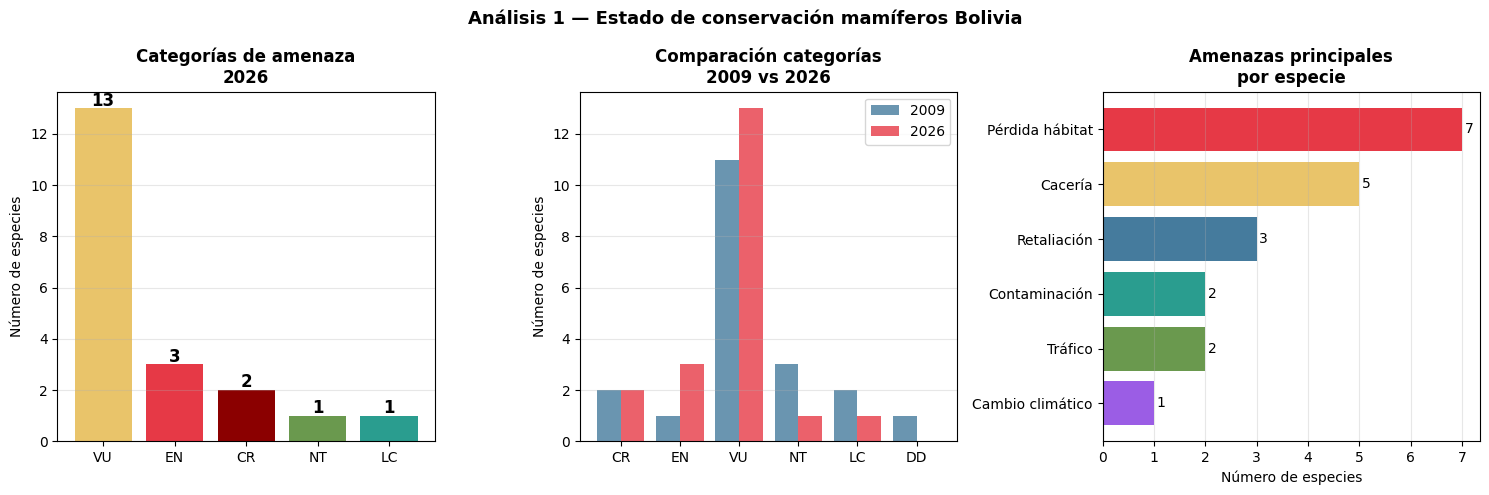


Hallazgos:
  Especies amenazadas (CR+EN+VU) : 18/20
  Amenaza más frecuente          : Pérdida de hábitat (7 especies)
  Especies que empeoraron        : 6 desde 2009


In [3]:
# ANÁLISIS 1 — Categorías de amenaza y cambios 2009 vs 2026
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gráfica 1 — Categorías 2026
categorias = df["categoria_2026"].value_counts()
colores_cat = {"CR": "#8B0000", "EN": "#E63946", "VU": "#E9C46A",
               "NT": "#6A994E", "LC": "#2A9D8F"}
colores = [colores_cat[c] for c in categorias.index]
bars = axes[0].bar(categorias.index, categorias.values, color=colores)
for bar, val in zip(bars, categorias.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.1,
                str(val), ha="center", fontsize=12, fontweight="bold")
axes[0].set_title("Categorías de amenaza\n2026", fontweight="bold")
axes[0].set_ylabel("Número de especies")
axes[0].grid(axis="y", alpha=0.3)

# Gráfica 2 — Comparación 2009 vs 2026
orden_cat = ["CR", "EN", "VU", "NT", "LC", "DD", "NE"]
cat_2009 = df["categoria_2009"].value_counts().reindex(["CR","EN","VU","NT","LC","DD"], fill_value=0)
cat_2026 = df["categoria_2026"].value_counts().reindex(["CR","EN","VU","NT","LC","DD"], fill_value=0)
x = range(len(cat_2009))
axes[1].bar([i - 0.2 for i in x], cat_2009.values, width=0.4,
            color="#457B9D", label="2009", alpha=0.8)
axes[1].bar([i + 0.2 for i in x], cat_2026.values, width=0.4,
            color="#E63946", label="2026", alpha=0.8)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(cat_2009.index)
axes[1].set_title("Comparación categorías\n2009 vs 2026", fontweight="bold")
axes[1].set_ylabel("Número de especies")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

# Gráfica 3 — Amenazas principales
amenazas = df["amenaza_principal"].value_counts()
colores_a = ["#E63946", "#E9C46A", "#457B9D", "#2A9D8F", "#6A994E", "#9B5DE5"]
axes[2].barh(amenazas.index[::-1], amenazas.values[::-1], color=colores_a[::-1])
for i, val in enumerate(amenazas.values[::-1]):
    axes[2].text(val + 0.05, i, str(val), va="center", fontsize=10)
axes[2].set_title("Amenazas principales\npor especie", fontweight="bold")
axes[2].set_xlabel("Número de especies")
axes[2].grid(axis="x", alpha=0.3)

plt.suptitle("Análisis 1 — Estado de conservación mamíferos Bolivia",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nHallazgos:")
print(f"  Especies amenazadas (CR+EN+VU) : {len(df[df['categoria_2026'].isin(['CR','EN','VU'])])}/20")
print(f"  Amenaza más frecuente          : Pérdida de hábitat (7 especies)")
print(f"  Especies que empeoraron        : {df['empeoro'].sum()} desde 2009")

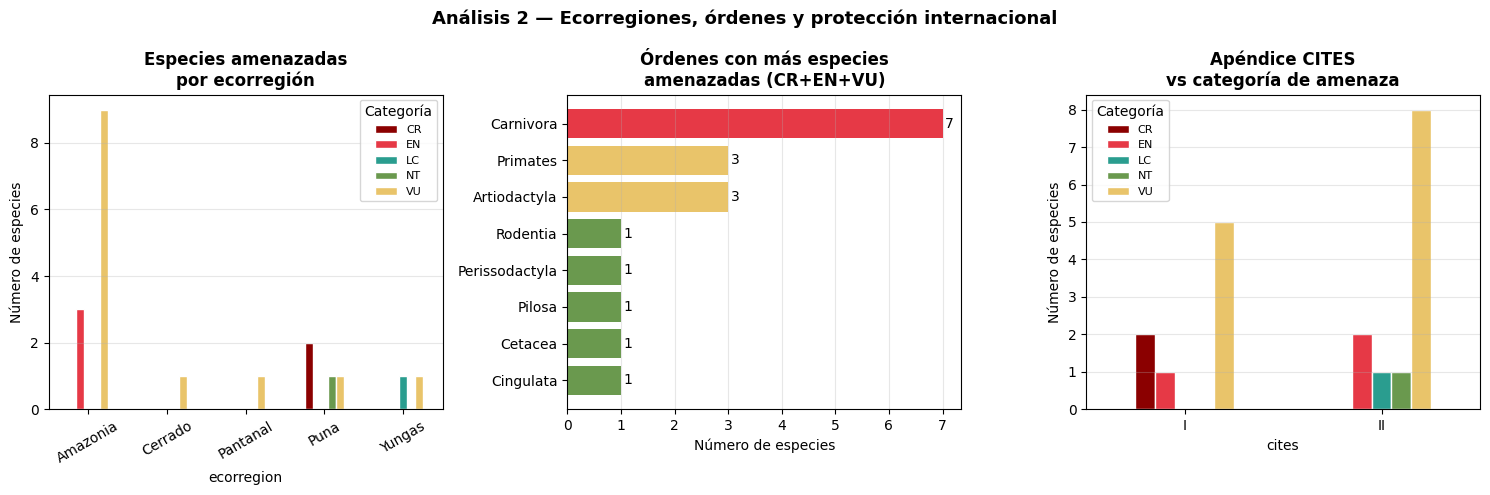


Hallazgos:
  Ecorregión más crítica   : Amazonia (3 especies CR/EN)
  Orden más amenazado      : Carnivora (7 especies)
  En CITES Apéndice I      : 8 especies (comercio prohibido)


In [5]:
# ANÁLISIS 2 — Ecorregiones y órdenes
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gráfica 1 — Especies por ecorregión
eco_cat = df.groupby(["ecorregion", "categoria_2026"]).size().unstack(fill_value=0)
colores_eco = {"CR": "#8B0000", "EN": "#E63946", "VU": "#E9C46A",
               "NT": "#6A994E", "LC": "#2A9D8F"}
eco_cat.plot(kind="bar", ax=axes[0], color=[colores_eco.get(c, "#aaa")
             for c in eco_cat.columns], edgecolor="white")
axes[0].set_title("Especies amenazadas\npor ecorregión", fontweight="bold")
axes[0].set_ylabel("Número de especies")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(title="Categoría", fontsize=8)
axes[0].grid(axis="y", alpha=0.3)

# Gráfica 2 — Órdenes más amenazados
orden_count = df[df["categoria_2026"].isin(["CR","EN","VU"])].groupby("orden").size()
orden_count = orden_count.sort_values(ascending=True)
colores_o = ["#E63946" if v >= 4 else "#E9C46A" if v >= 2 else "#6A994E"
             for v in orden_count.values]
axes[1].barh(orden_count.index, orden_count.values, color=colores_o)
for i, val in enumerate(orden_count.values):
    axes[1].text(val + 0.05, i, str(val), va="center", fontsize=10)
axes[1].set_title("Órdenes con más especies\namenazadas (CR+EN+VU)", fontweight="bold")
axes[1].set_xlabel("Número de especies")
axes[1].grid(axis="x", alpha=0.3)

# Gráfica 3 — CITES vs categoría
cites_cat = df.groupby(["cites", "categoria_2026"]).size().unstack(fill_value=0)
cites_cat.plot(kind="bar", ax=axes[2], color=[colores_eco.get(c, "#aaa")
               for c in cites_cat.columns], edgecolor="white")
axes[2].set_title("Apéndice CITES\nvs categoría de amenaza", fontweight="bold")
axes[2].set_ylabel("Número de especies")
axes[2].tick_params(axis="x", rotation=0)
axes[2].legend(title="Categoría", fontsize=8)
axes[2].grid(axis="y", alpha=0.3)

plt.suptitle("Análisis 2 — Ecorregiones, órdenes y protección internacional",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nHallazgos:")
eco_critica = df[df["categoria_2026"].isin(["CR","EN"])]["ecorregion"].value_counts()
print(f"  Ecorregión más crítica   : {eco_critica.index[0]} ({eco_critica.values[0]} especies CR/EN)")
orden_top = orden_count.index[-1]
print(f"  Orden más amenazado      : {orden_top} ({orden_count.values[-1]} especies)")
cites1 = len(df[df["cites"]=="I"])
print(f"  En CITES Apéndice I      : {cites1} especies (comercio prohibido)")

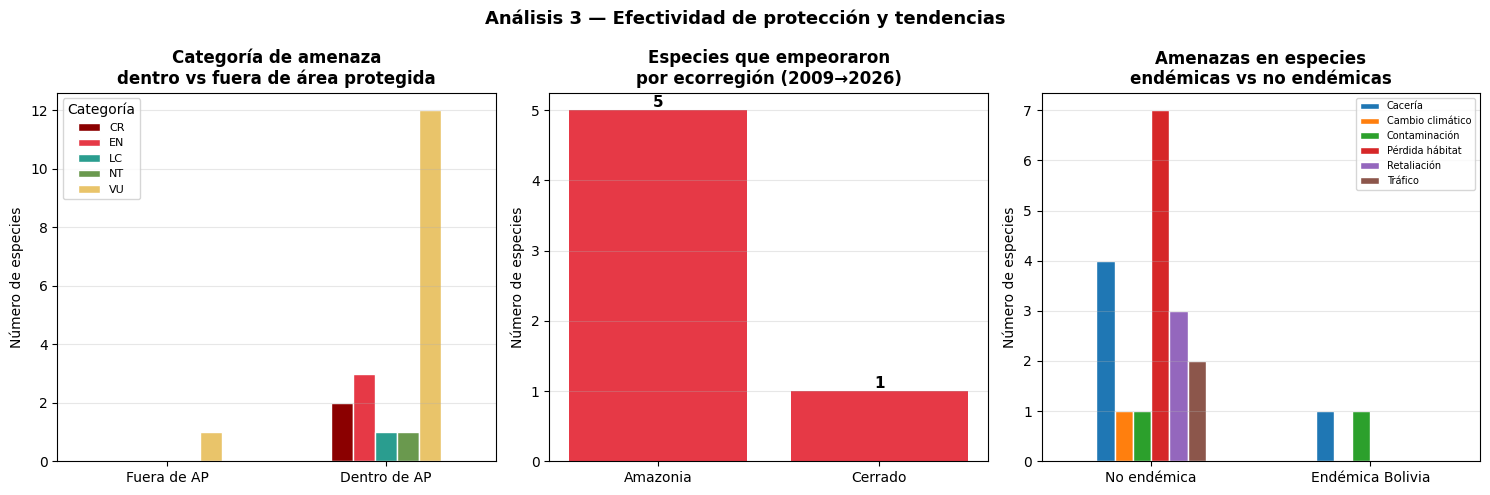


Hallazgos:
  Especies CR/EN dentro de AP : 5 — las áreas protegidas no garantizan seguridad
  Especies que empeoraron     : 6
  Ecorregión con más deterioro: Amazonia (5 especies)
  Especies endémicas amenazadas: 2/2


In [6]:
# ANÁLISIS 3 — Áreas protegidas y especies que empeoraron
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gráfica 1 — Categoría dentro vs fuera de área protegida
ap_cat = df.groupby(["en_area_protegida", "categoria_2026"]).size().unstack(fill_value=0)
ap_cat.index = ["Fuera de AP", "Dentro de AP"]
ap_cat.plot(kind="bar", ax=axes[0], color=[colores_eco.get(c, "#aaa")
            for c in ap_cat.columns], edgecolor="white")
axes[0].set_title("Categoría de amenaza\ndentro vs fuera de área protegida",
                  fontweight="bold")
axes[0].set_ylabel("Número de especies")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Categoría", fontsize=8)
axes[0].grid(axis="y", alpha=0.3)

# Gráfica 2 — Especies que empeoraron por ecorregión
empeoraron = df[df["empeoro"]==True]
eco_emp = empeoraron["ecorregion"].value_counts()
axes[1].bar(eco_emp.index, eco_emp.values, color="#E63946")
for i, val in enumerate(eco_emp.values):
    axes[1].text(i, val + 0.05, str(val), ha="center", fontsize=11, fontweight="bold")
axes[1].set_title("Especies que empeoraron\npor ecorregión (2009→2026)",
                  fontweight="bold")
axes[1].set_ylabel("Número de especies")
axes[1].grid(axis="y", alpha=0.3)

# Gráfica 3 — Amenazas en especies endémicas vs no endémicas
end_amenaza = df.groupby(["endemica_bolivia", "amenaza_principal"]).size().unstack(fill_value=0)
end_amenaza.index = ["No endémica", "Endémica Bolivia"]
end_amenaza.plot(kind="bar", ax=axes[2], edgecolor="white")
axes[2].set_title("Amenazas en especies\nendémicas vs no endémicas",
                  fontweight="bold")
axes[2].set_ylabel("Número de especies")
axes[2].tick_params(axis="x", rotation=0)
axes[2].legend(fontsize=7)
axes[2].grid(axis="y", alpha=0.3)

plt.suptitle("Análisis 3 — Efectividad de protección y tendencias",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nHallazgos:")
dentro_ap = df[df["en_area_protegida"]==True]
cr_en_dentro = len(dentro_ap[dentro_ap["categoria_2026"].isin(["CR","EN"])])
print(f"  Especies CR/EN dentro de AP : {cr_en_dentro} — las áreas protegidas no garantizan seguridad")
print(f"  Especies que empeoraron     : {len(empeoraron)}")
print(f"  Ecorregión con más deterioro: {eco_emp.index[0]} ({eco_emp.values[0]} especies)")
print(f"  Especies endémicas amenazadas: {len(df[(df['endemica_bolivia']==True) & (df['categoria_2026'].isin(['CR','EN','VU']))])}/2")

In [7]:
# INFORME FINAL
print("=" * 60)
print("   LIBRO ROJO DE MAMÍFEROS DE BOLIVIA 2026")
print("   Análisis de 20 especies amenazadas")
print("   Fuente: Ministerio de Planificación y Medio Ambiente")
print("=" * 60)

amenazadas = len(df[df["categoria_2026"].isin(["CR","EN","VU"])])
cr = len(df[df["categoria_2026"]=="CR"])
en = len(df[df["categoria_2026"]=="EN"])
vu = len(df[df["categoria_2026"]=="VU"])
cites1 = len(df[df["cites"]=="I"])

print(f"""
HALLAZGO 1 — ESTADO DE AMENAZA 2026
--------------------------------------
Especies analizadas          : 20
Especies amenazadas (CR+EN+VU): {amenazadas} ({amenazadas/20*100:.0f}%)
  En Peligro Crítico (CR)    : {cr} — Chinchilla, Gato andino
  En Peligro (EN)            : {en} — Bufeo, Londra, Marimono
  Vulnerables (VU)           : {vu} especies
Especies que empeoraron      : 6 desde 2009
Comercio prohibido (CITES I) : {cites1} especies

HALLAZGO 2 — ECORREGIONES Y ÓRDENES
--------------------------------------
Ecorregión más crítica       : Amazonia (12 especies amenazadas)
Ecorregión con más deterioro : Amazonia (5 especies empeoraron)
Orden más amenazado          : Carnivora (7 especies)
Especies endémicas Bolivia   : 2/2 están amenazadas
  — Bufeo (Inia boliviensis) : EN peligro
  — Manechi colorado        : Vulnerable

HALLAZGO 3 — PROTECCIÓN Y AMENAZAS
--------------------------------------
Especies CR/EN en áreas prot.: 5 — protección insuficiente
Amenaza principal            : Pérdida de hábitat (7 especies)
Otras amenazas críticas      : Cacería (5), Retaliación (3)
Incendios desde 2019         : Factor crítico en Amazonia

REFLEXIÓN FINAL
-----------------
Bolivia alberga el 90% de sus mamíferos emblemáticos
en alguna categoría de amenaza. El Bufeo boliviano —
único delfín de río endémico del país — está EN PELIGRO.
La Chinchilla boliviana está en PELIGRO CRÍTICO.
Las áreas protegidas existen pero no son suficientes.
La pérdida de hábitat avanza más rápido que las
políticas de conservación.
""")
print("=" * 60)

   LIBRO ROJO DE MAMÍFEROS DE BOLIVIA 2026
   Análisis de 20 especies amenazadas
   Fuente: Ministerio de Planificación y Medio Ambiente

HALLAZGO 1 — ESTADO DE AMENAZA 2026
--------------------------------------
Especies analizadas          : 20
Especies amenazadas (CR+EN+VU): 18 (90%)
  En Peligro Crítico (CR)    : 2 — Chinchilla, Gato andino
  En Peligro (EN)            : 3 — Bufeo, Londra, Marimono
  Vulnerables (VU)           : 13 especies
Especies que empeoraron      : 6 desde 2009
Comercio prohibido (CITES I) : 8 especies

HALLAZGO 2 — ECORREGIONES Y ÓRDENES
--------------------------------------
Ecorregión más crítica       : Amazonia (12 especies amenazadas)
Ecorregión con más deterioro : Amazonia (5 especies empeoraron)
Orden más amenazado          : Carnivora (7 especies)
Especies endémicas Bolivia   : 2/2 están amenazadas
  — Bufeo (Inia boliviensis) : EN peligro
  — Manechi colorado        : Vulnerable

HALLAZGO 3 — PROTECCIÓN Y AMENAZAS
-----------------------------------

In [8]:
# Exportar para SQL
df.to_csv("mamiferos_bolivia.csv", index=False)
print("✅ Archivo exportado")

✅ Archivo exportado
